In [1]:
from neuromaps import NeuroMapTargetNormalized, CoupledOscillators
import numpy as np
from systems import coupled_oscillators_rk4, coupled_oscillators_right_part
from utils import get_attractor_trajectory

model1 = NeuroMapTargetNormalized.load("../single_vdp_nm_2/checkpoints/model.ckpt")
model2 = NeuroMapTargetNormalized.load("../single_vdp_nm_2/checkpoints/model.ckpt")

neuromap = CoupledOscillators(model1, model2)

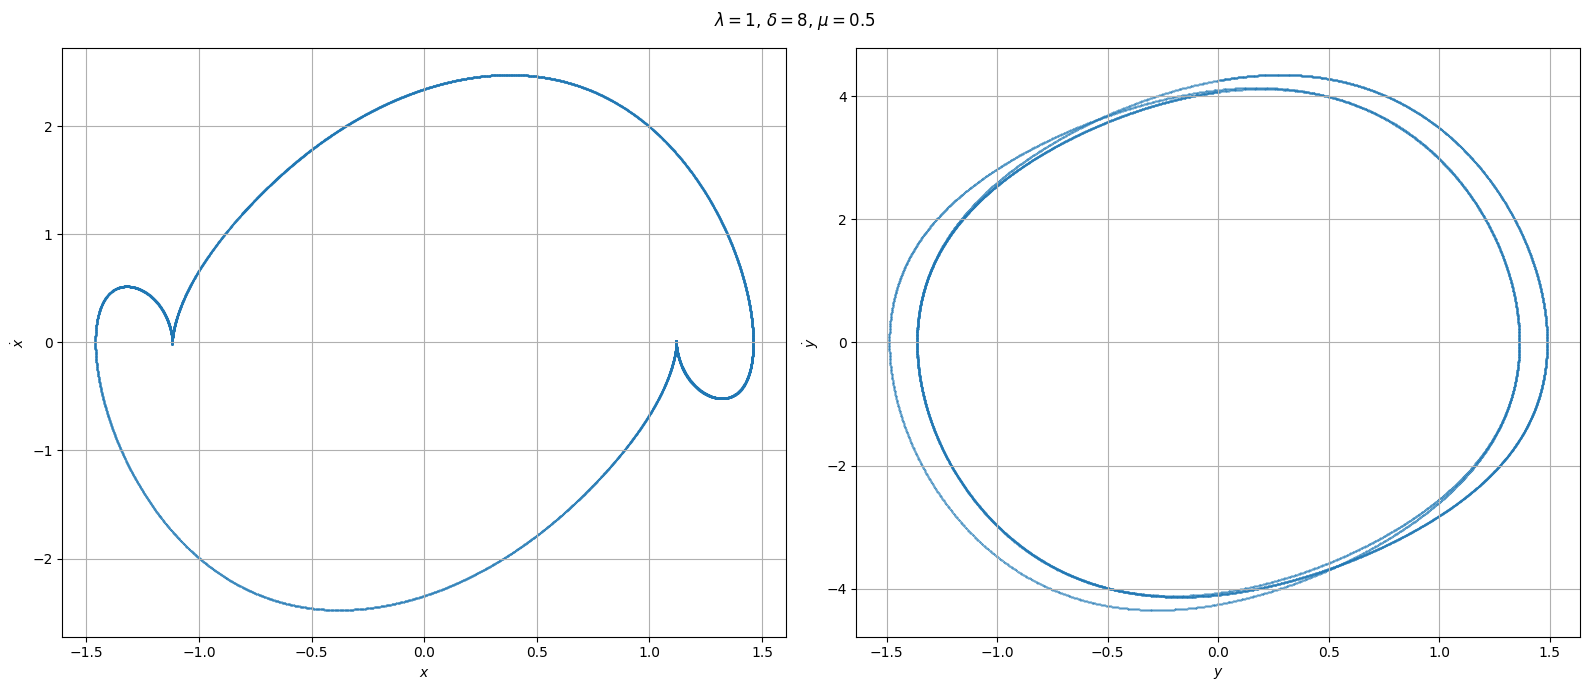

In [3]:
delta = 8
mu = 0.5

# [λ1, ω₀²₁, λ2, ω₀²₂, ε]
params = np.array([1, 1, 1, 1 + delta, mu])
u0 = np.array([0.7, 0.5, 0.8, 0.6])

# Секущая плоскость: x'1 = 0
secant_plane = lambda state, params: state[2]
secant_plane_derivatives = lambda state, params: np.array([0, 0, 1, 0])

trajectory = get_attractor_trajectory(
    evolution_operator=coupled_oscillators_rk4,
    right_part=coupled_oscillators_right_part,
    state=u0,
    params=params,
    dt=0.001,
    n_transient=50,
    n_attractor=100,
    secant_plane=secant_plane,
    secant_plane_derivatives=secant_plane_derivatives,
    accuracy=1e-4
)

from utils import plot_trajectory

plot_trajectory(trajectory, title=fr'$\lambda=1$, $\delta=${delta}, $\mu=${mu}')

Симуляция связанных осцилляторов: 100%|████████████████████| 50000/50000 [00:08<00:00, 5573.08шаг/s]


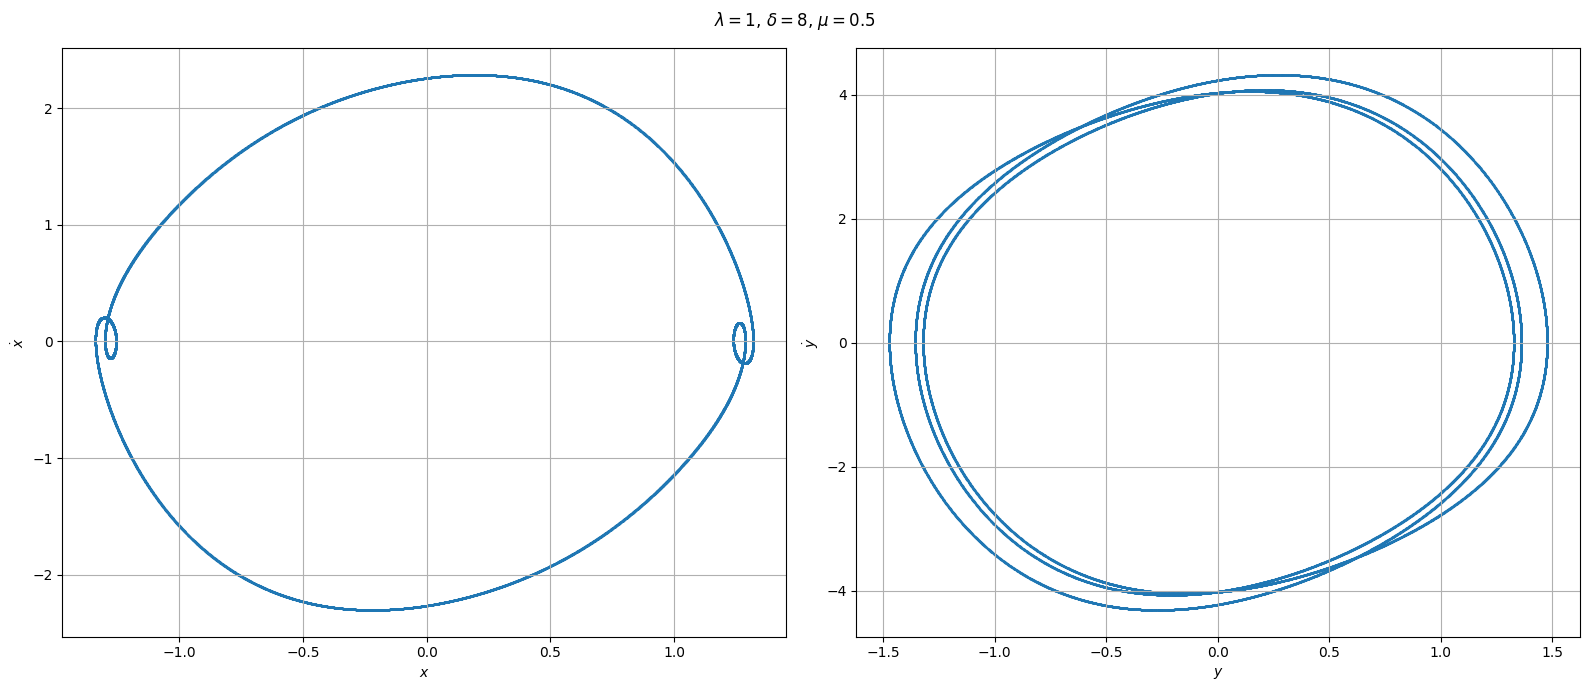

In [4]:
delta = 8
mu=0.5

trajectory = neuromap.simulate(
    u0=np.array([0.7, 0.5, 0.8, 0.6]),
    p=np.array([1, 1, 1, 1 + delta]), # [λ1, ω₀²₁, λ2, ω₀²₂]
    n_steps=50000,
    epsilon=mu,  # μ
    verbose=True
)

from utils import plot_trajectory

plot_trajectory(trajectory[10000:], title=fr'$\lambda=1$, $\delta=${delta}, $\mu=${mu}')

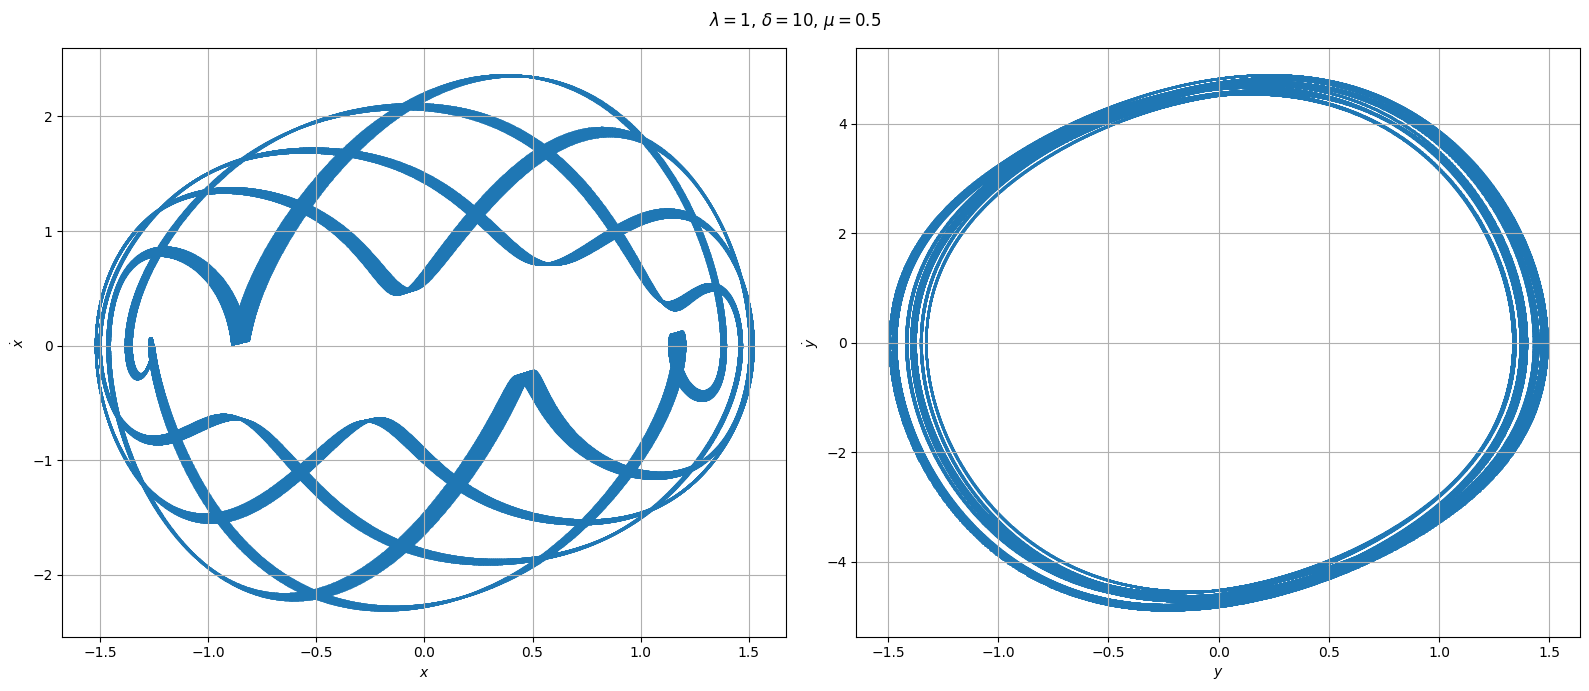

In [5]:
delta = 10
mu = 0.5

params = np.array([1, 1, 1, 1 + delta, mu])
u0 = np.array([0.7, 0.5, 0.8, 0.6])

secant_plane = lambda state, params: state[2]
secant_plane_derivatives = lambda state, params: np.array([0, 0, 1, 0])

trajectory = get_attractor_trajectory(
    evolution_operator=coupled_oscillators_rk4,
    right_part=coupled_oscillators_right_part,
    state=u0,
    params=params,
    dt=0.001,
    n_transient=50,
    n_attractor=300,
    secant_plane=secant_plane,
    secant_plane_derivatives=secant_plane_derivatives,
    accuracy=1e-4
)

from utils import plot_trajectory

plot_trajectory(trajectory, title=fr'$\lambda=1$, $\delta=${delta}, $\mu=${mu}')

Симуляция связанных осцилляторов: 100%|████████████████████| 50000/50000 [00:08<00:00, 5767.20шаг/s]


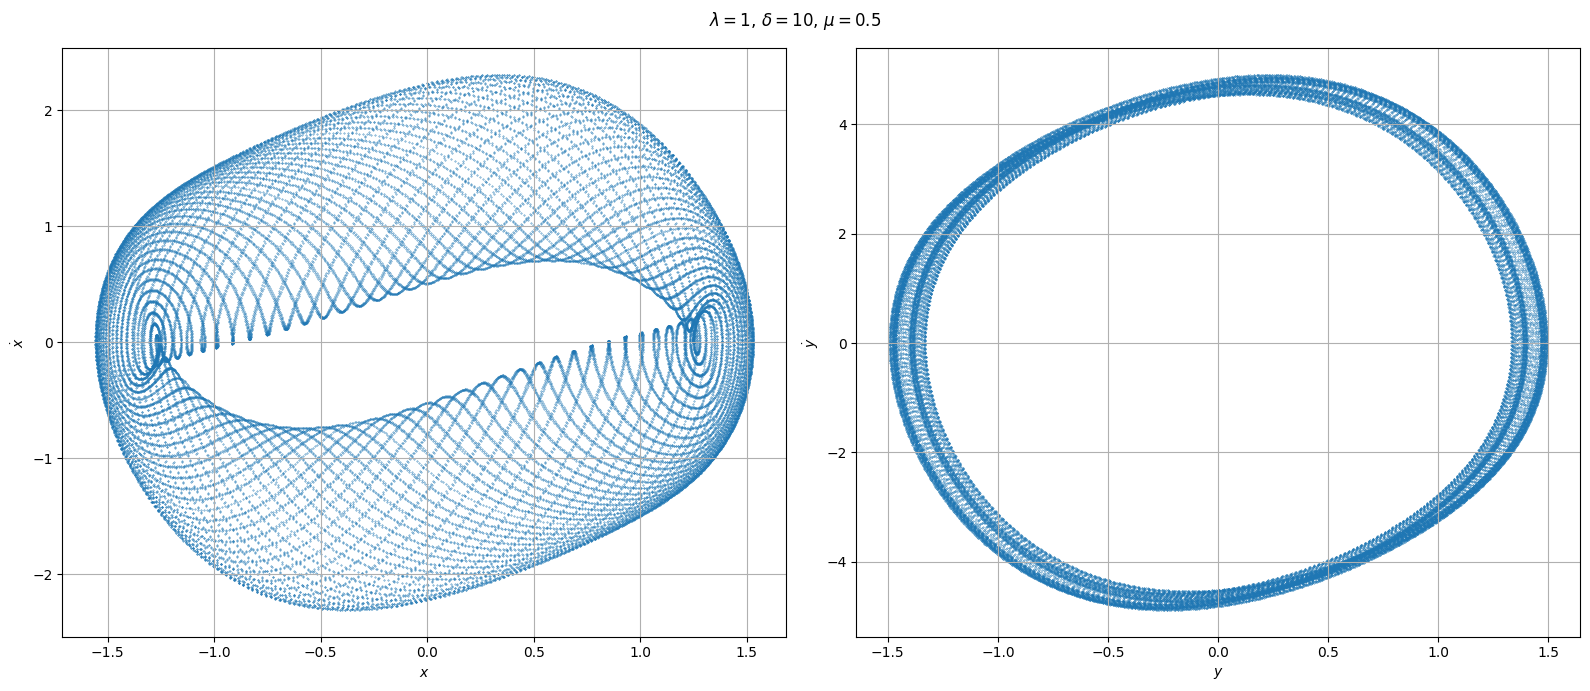

In [6]:
delta = 10
mu=0.5

trajectory = neuromap.simulate(
    u0=np.array([0.7, 0.5, 0.8, 0.6]),
    p=np.array([1, 1, 1, 1 + delta]), # [λ1, ω₀²₁, λ2, ω₀²₂]
    n_steps=50000,
    epsilon=mu,  # μ
    verbose=True
)

from utils import plot_trajectory

plot_trajectory(trajectory[10000:], title=fr'$\lambda=1$, $\delta=${delta}, $\mu=${mu}')